In [1]:
import os
import sys
import scanpy as sc
from pathlib import Path
import mofaflex as mfl
import pandas as pd

sys.path.append("docs/source/unfinished_temp_notebooks/MOFA_Flex/")

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
from helper_functions import evaluate_pipeline
from helper_functions import plot_model_metrics
from helper_functions import summarize_cluster_spatial_metrics

In [3]:
models_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/mofa_models")
merfish_path = Path("/g/stegle/aalsayah/repos/data/merfish/mouse_brain/lrdata")
lrdata = sc.read(merfish_path / "WB_MERFISH_animal2_coronal_lrdata.h5ad")

# Evaluate models

In [4]:
model= mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_Normal.hdf5")

# Cell 8: Run everything
results_norm = evaluate_pipeline(
    model=model,
    lrdata=lrdata,
    output_dir="eval_output",
    group="group_1",
    n_clusters_list=range(2,10),
    obs_keys=["major_brain_region", "cell_type"],
    classification_label_key="major_brain_region",
    spatial_key="X_spatial_coords"
)


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: eval_output/plots/factor_correlation.png
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: eval_output/plots/variance_explained.png


In [5]:
model= mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_GP_SnS.hdf5")
results_GP_SnS = evaluate_pipeline(
    model=model,
    lrdata=lrdata,
    output_dir="eval_output",
    group="group_1",
    n_clusters_list=range(2,10),
    obs_keys=["major_brain_region", "cell_type"],
    classification_label_key="major_brain_region",
    spatial_key="X_spatial_coords"
)


/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: eval_output/plots/factor_correlation.png
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: eval_output/plots/variance_explained.png


In [6]:
model= mfl.MOFAFLEX.load(models_path / "WB_MERFISH_animal2_coronal_nonneg.hdf5")
results_nonneg = evaluate_pipeline(
    model=model,
    lrdata=lrdata,
    output_dir="eval_output",
    group="group_1",
    n_clusters_list=range(2,10),
    obs_keys=["major_brain_region", "cell_type"],
    classification_label_key="major_brain_region",
    spatial_key="X_spatial_coords"
)

/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: eval_output/plots/factor_correlation.png
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 8 x 8 in image.
/g/stegle/aalsayah/Miniforge3/envs/mofa_flex/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: eval_output/plots/variance_explained.png


# PLOT

In [7]:
models = {
    "Normal_Priors": results_norm,
    "Non_Negativity": results_nonneg,
    "GP_SnS": results_GP_SnS,
}

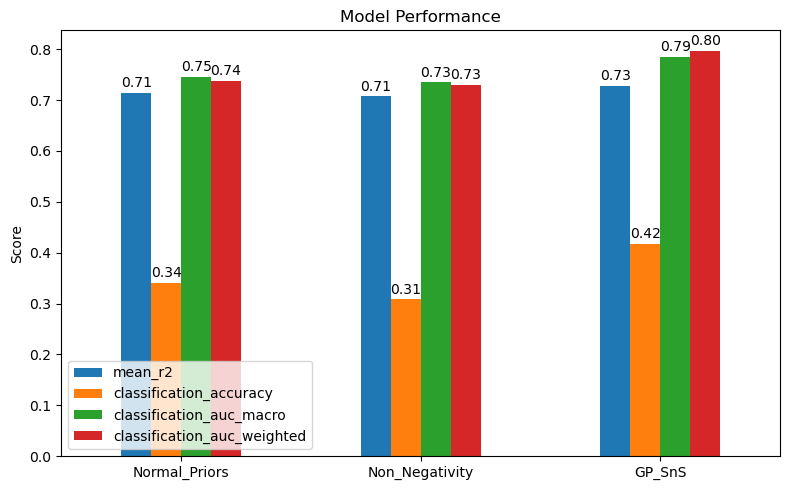

In [8]:
metrics = ["mean_r2", "classification_accuracy", "classification_auc_macro", "classification_auc_weighted"]

plot_model_metrics(models, metrics, figsize=(8, 5), title="Model Performance", rotate_xticks=0)

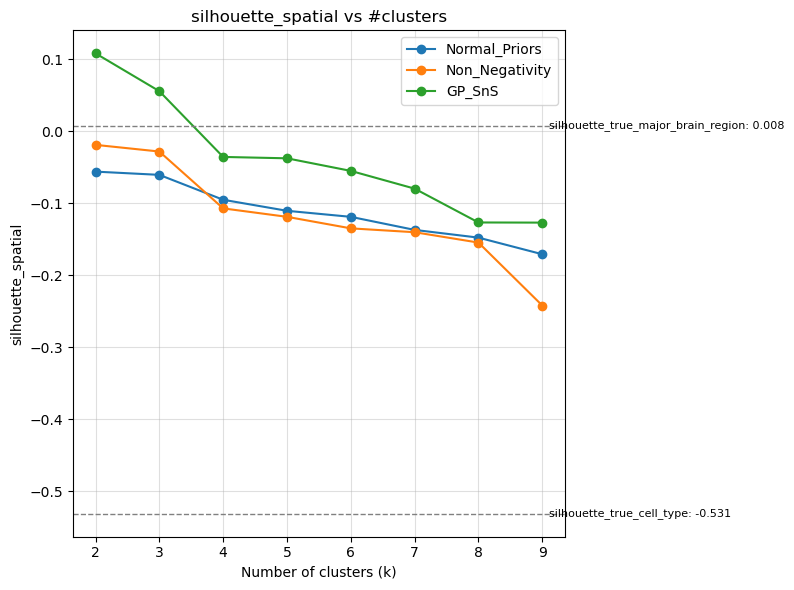

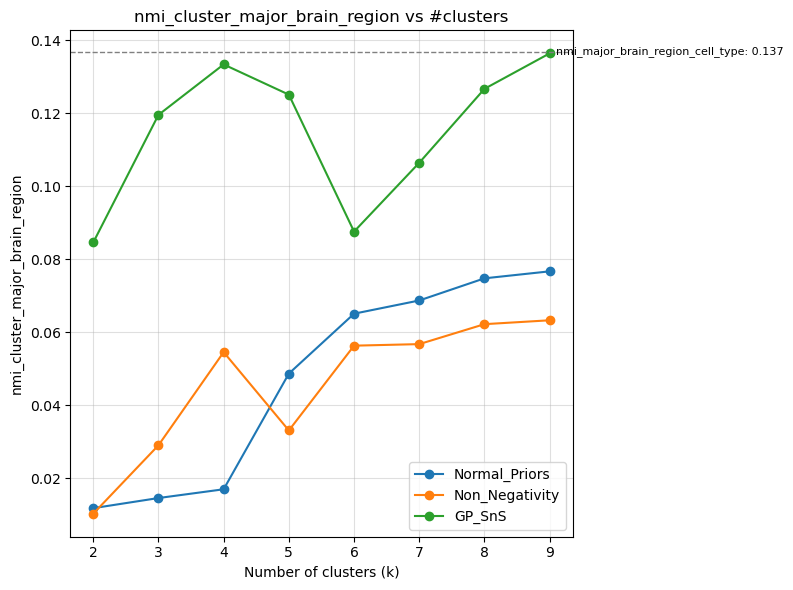

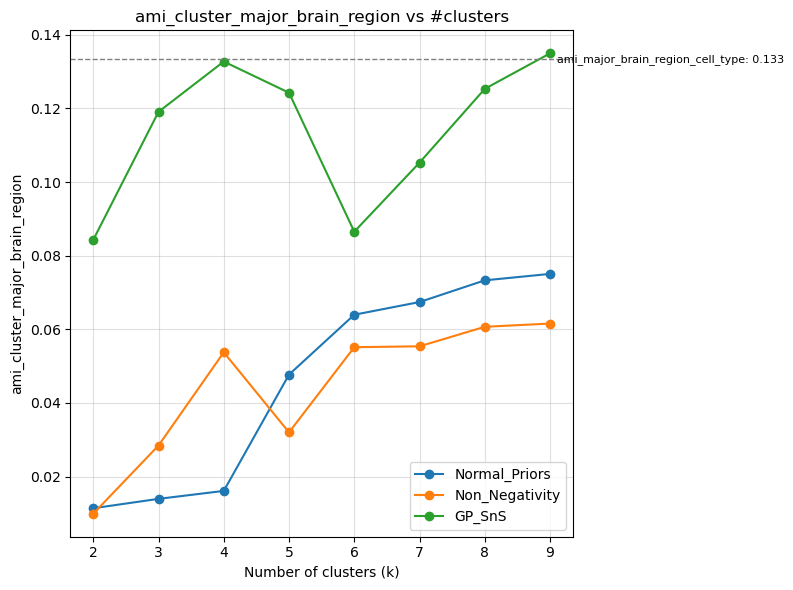

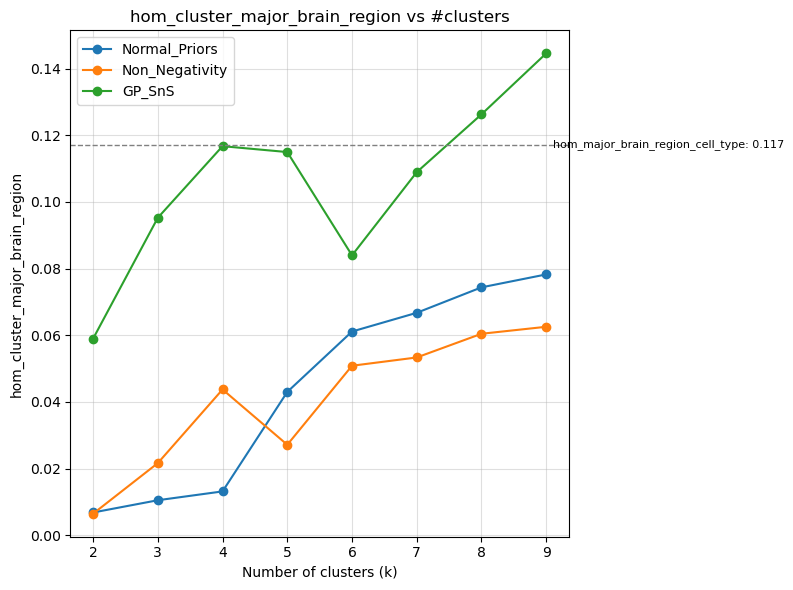

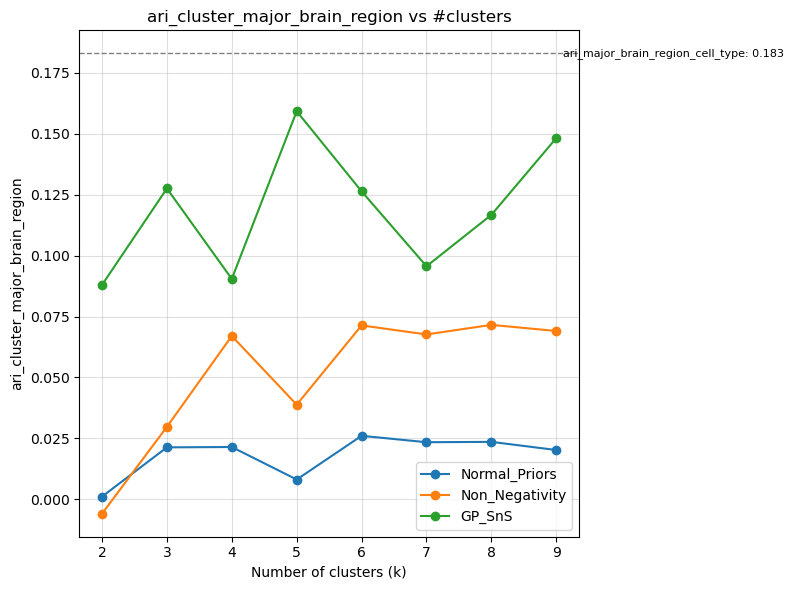

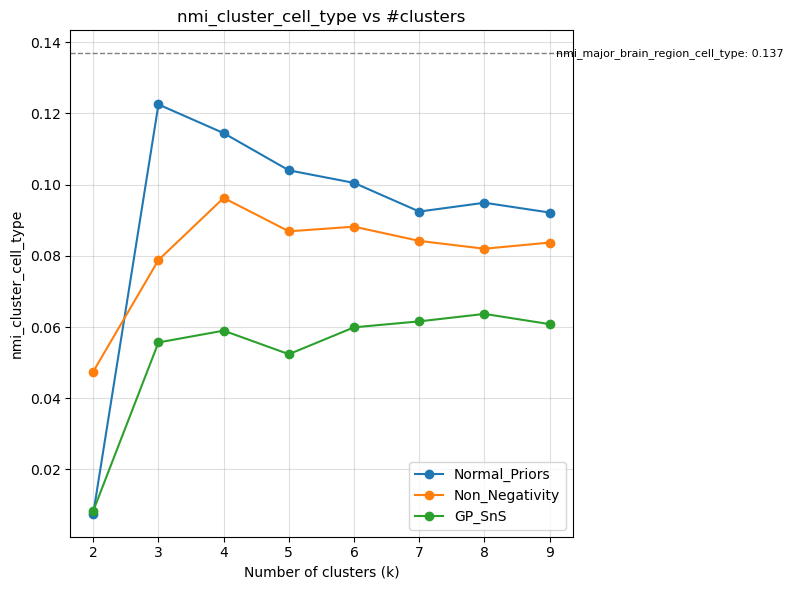

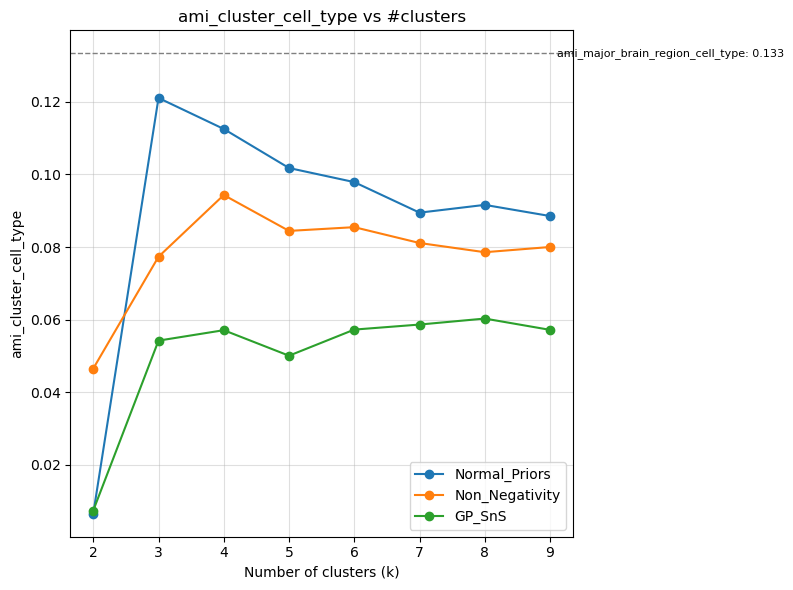

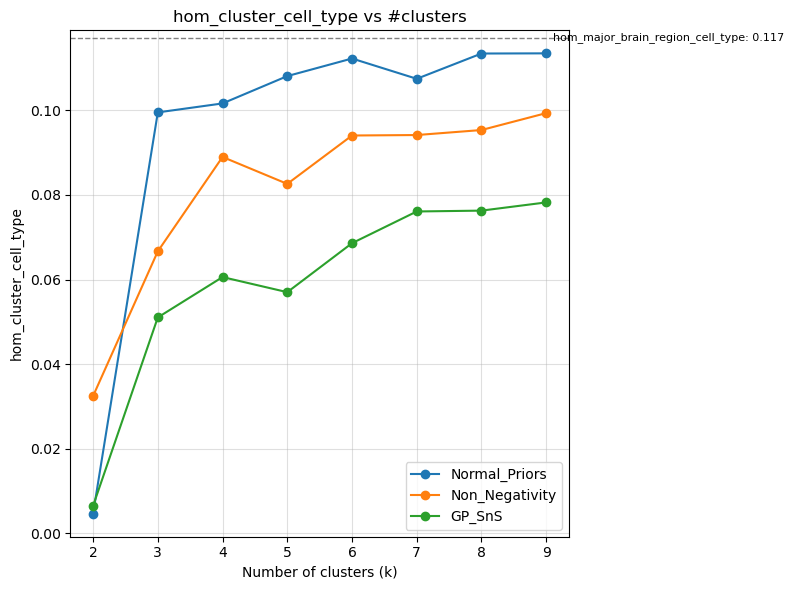

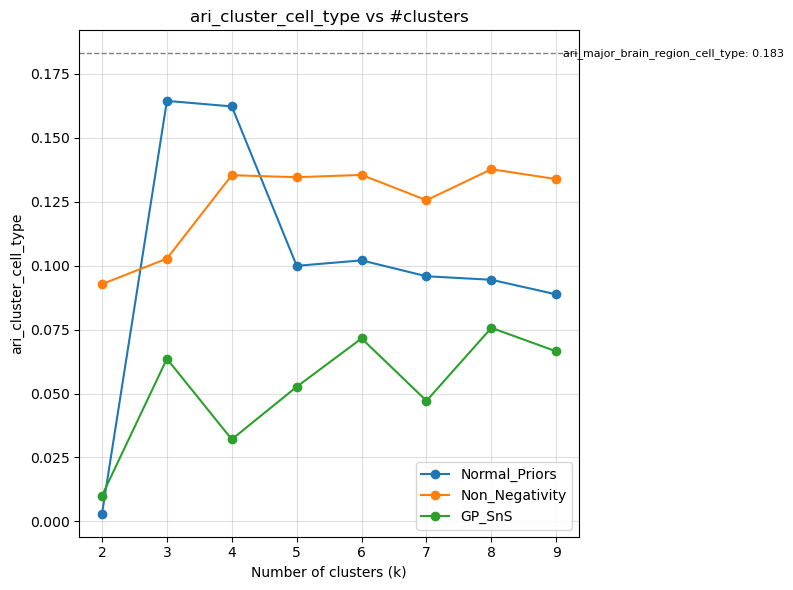

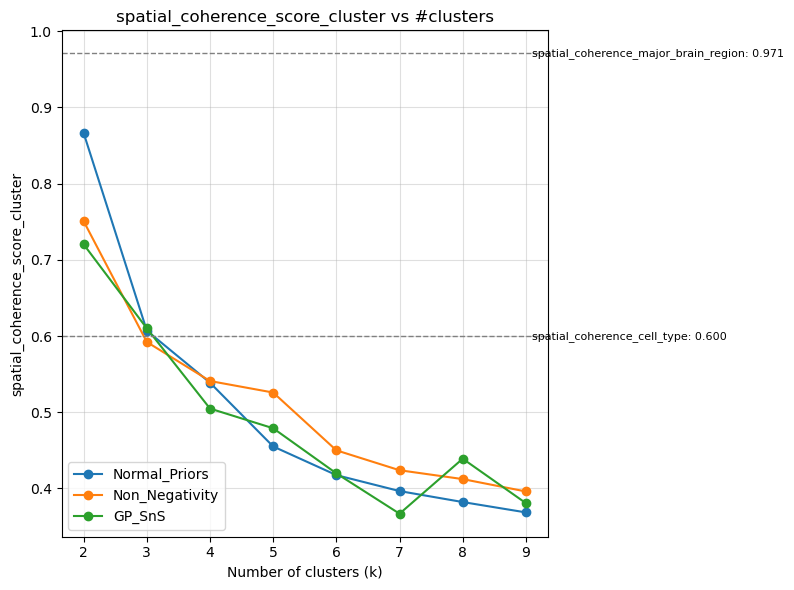

In [10]:
summarize_cluster_spatial_metrics(models, plot=True)